In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pickle

In [3]:
df = pd.read_csv("../data/customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
print("Current columns:", df.columns.tolist())

Current columns: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']


In [5]:
df.columns = df.columns.str.strip()

In [6]:
df = df.rename(columns={
    'Annual Income (k$)': 'AnnualIncome (k$)',
    'Spending Score (1-100)': 'SpendingScore(1-100)'
})

In [7]:
X = df[["AnnualIncome (k$)", "SpendingScore(1-100)"]]

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

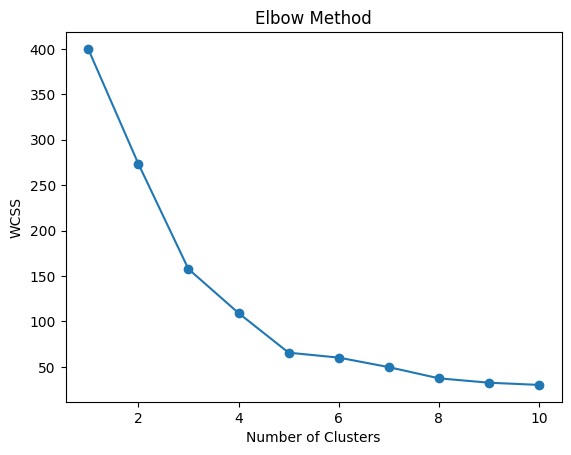

In [9]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [10]:
# Train Final Model
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters

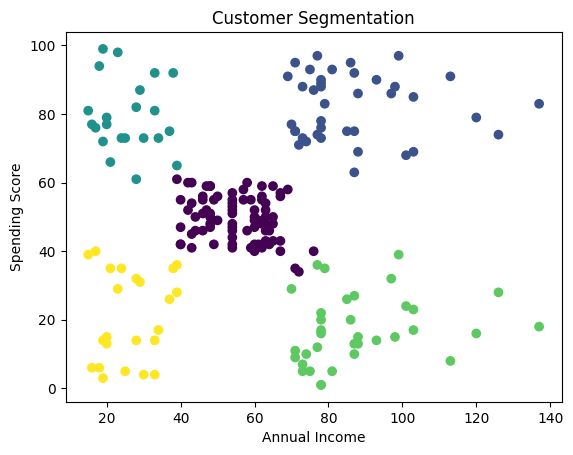

In [13]:
plt.scatter(
    df["AnnualIncome (k$)"],
    df["SpendingScore(1-100)"],
    c=df["Cluster"],
    cmap="viridis"
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")

plt.show()

In [14]:
with open("../model/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

In [17]:
sample = pd.DataFrame([[60000, 40]], 
                      columns=['AnnualIncome (k$)', 'SpendingScore(1-100)'])


sample_scaled = scaler.transform(sample)
cluster = kmeans.predict(sample_scaled)

print(f"Customer belongs to cluster: {cluster[0]}")

Customer belongs to cluster: 3


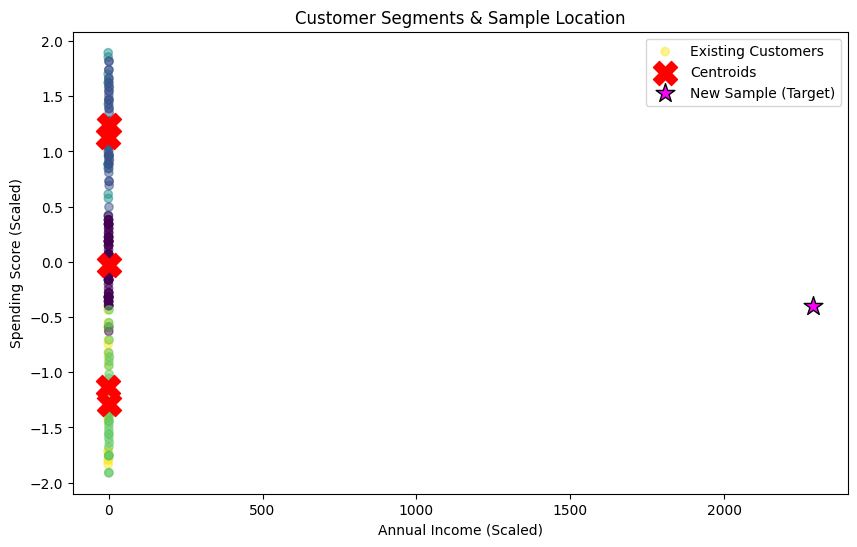

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=kmeans.labels_, cmap='viridis', alpha=0.5, label='Existing Customers')


plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], 
            s=300, c='red', marker='X', label='Centroids')


plt.scatter(sample_scaled[0, 0], sample_scaled[0, 1], 
            s=200, c='magenta', edgecolors='black', marker='*', label='New Sample (Target)')

plt.title("Customer Segments & Sample Location")
plt.xlabel("Annual Income (Scaled)")
plt.ylabel("Spending Score (Scaled)")
plt.legend()
plt.show()
